In [ ]:
from google.colab import files
uploaded=files.upload()
import pandas as pd
import numpy as np
df = pd.read_excel("Predictive.xlsx")
print("Dataset Loaded Successfully")
print("Shape:", df.shape)
df.head()

Saving Predictive.xlsx to Predictive.xlsx
Dataset Loaded Successfully
Shape: (782, 58)


,Age,BMI,Sex,Height,Weight,Length_of_Stay,Management,Severity,Diagnosis_Presumptive,Diagnosis,...,Abscess_Location,Pathological_Lymph_Nodes,Lymph_Nodes_Location,Bowel_Wall_Thickening,Conglomerate_of_Bowel_Loops,Ileus,Coprostasis,Meteorism,Enteritis,Gynecological_Findings
0,12.68,16.9,female,148.0,37.0,3.0,conservative,uncomplicated,appendicitis,appendicitis,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14.10,31.9,male,147.0,69.5,2.0,conservative,uncomplicated,appendicitis,no appendicitis,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN
2,14.14,23.3,female,163.0,62.0,4.0,conservative,uncomplicated,appendicitis,no appendicitis,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,yes,NaN
3,16.37,20.6,female,165.0,56.0,3.0,conservative,uncomplicated,appendicitis,no appendicitis,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,yes,NaN
4,11.08,16.9,female,163.0,45.0,3.0,conservative,uncomplicated,appendicitis,appendicitis,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,yes,NaN


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
print("Dataset Info:\n")
df.info()
print("\nMissing Values per Column:\n")
df.isnull().sum()


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               781 non-null    float64
 1   BMI                               755 non-null    float64
 2   Sex                               780 non-null    object 
 3   Height                            756 non-null    float64
 4   Weight                            779 non-null    float64
 5   Length_of_Stay                    778 non-null    float64
 6   Management                        781 non-null    object 
 7   Severity                          781 non-null    object 
 8   Diagnosis_Presumptive             780 non-null    object 
 9   Diagnosis                         780 non-null    object 
 10  Alvarado_Score                    730 non-null    float64
 11  Paedriatic_Appendicitis_Score     730 non-null    float6

,0
Age,1
BMI,27
Sex,2
Height,26
Weight,3
Length_of_Stay,4
Management,1
Severity,1
Diagnosis_Presumptive,2
Diagnosis,2


In [ ]:
df.describe(include="all")

,Age,BMI,Sex,Height,Weight,Length_of_Stay,Management,Severity,Diagnosis_Presumptive,Diagnosis,...,Abscess_Location,Pathological_Lymph_Nodes,Lymph_Nodes_Location,Bowel_Wall_Thickening,Conglomerate_of_Bowel_Loops,Ileus,Coprostasis,Meteorism,Enteritis,Gynecological_Findings
count,781.000000,755.000000,780,756.000000,779.000000,778.000000,781,781,780,780,...,13,203,121,99,43,60,71,140,66,26
unique,NaN,NaN,2,NaN,NaN,NaN,4,2,16,2,...,7,2,26,2,2,2,2,2,2,14
top,NaN,NaN,male,NaN,NaN,NaN,conservative,uncomplicated,appendicitis,appendicitis,...,Douglas,yes,mesenterial,yes,no,no,yes,yes,yes,keine
freq,NaN,NaN,403,NaN,NaN,NaN,483,662,682,463,...,6,154,37,55,22,37,46,129,51,9
mean,11.346483,18.906916,NaN,148.017460,43.172542,4.284062,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,3.529979,4.385252,NaN,19.732016,17.390984,2.574057,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,7.827983,NaN,53.000000,3.960000,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,9.200000,15.725294,NaN,137.000000,29.500000,3.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,11.438741,18.062284,NaN,149.650000,41.400000,3.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,14.099932,21.179011,NaN,163.000000,54.000000,5.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Dataset Shape:", df.shape)
print(df.head())
print("\nColumn Names:")
df.columns.tolist()

Dataset Shape: (782, 58)
     Age   BMI     Sex  Height  Weight  Length_of_Stay    Management  \
0  12.68  16.9  female   148.0    37.0             3.0  conservative   
1  14.10  31.9    male   147.0    69.5             2.0  conservative   
2  14.14  23.3  female   163.0    62.0             4.0  conservative   
3  16.37  20.6  female   165.0    56.0             3.0  conservative   
4  11.08  16.9  female   163.0    45.0             3.0  conservative   

        Severity Diagnosis_Presumptive        Diagnosis  ...  \
0  uncomplicated          appendicitis     appendicitis  ...   
1  uncomplicated          appendicitis  no appendicitis  ...   
2  uncomplicated          appendicitis  no appendicitis  ...   
3  uncomplicated          appendicitis  no appendicitis  ...   
4  uncomplicated          appendicitis     appendicitis  ...   

   Abscess_Location  Pathological_Lymph_Nodes Lymph_Nodes_Location  \
0               NaN                       yes                 reUB   
1               N

['Age',
 'BMI',
 'Sex',
 'Height',
 'Weight',
 'Length_of_Stay',
 'Management',
 'Severity',
 'Diagnosis_Presumptive',
 'Diagnosis',
 'Alvarado_Score',
 'Paedriatic_Appendicitis_Score',
 'Appendix_on_US',
 'Appendix_Diameter',
 'Migratory_Pain',
 'Lower_Right_Abd_Pain',
 'Contralateral_Rebound_Tenderness',
 'Coughing_Pain',
 'Nausea',
 'Loss_of_Appetite',
 'Body_Temperature',
 'WBC_Count',
 'Neutrophil_Percentage',
 'Segmented_Neutrophils',
 'Neutrophilia',
 'RBC_Count',
 'Hemoglobin',
 'RDW',
 'Thrombocyte_Count',
 'Ketones_in_Urine',
 'RBC_in_Urine',
 'WBC_in_Urine',
 'CRP',
 'Dysuria',
 'Stool',
 'Peritonitis',
 'Psoas_Sign',
 'Ipsilateral_Rebound_Tenderness',
 'US_Performed',
 'US_Number',
 'Free_Fluids',
 'Appendix_Wall_Layers',
 'Target_Sign',
 'Appendicolith',
 'Perfusion',
 'Perforation',
 'Surrounding_Tissue_Reaction',
 'Appendicular_Abscess',
 'Abscess_Location',
 'Pathological_Lymph_Nodes',
 'Lymph_Nodes_Location',
 'Bowel_Wall_Thickening',
 'Conglomerate_of_Bowel_Loops',
 '

In [ ]:
print(df.info())
print("\nData Types:")
df.dtypes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               781 non-null    float64
 1   BMI                               755 non-null    float64
 2   Sex                               780 non-null    object 
 3   Height                            756 non-null    float64
 4   Weight                            779 non-null    float64
 5   Length_of_Stay                    778 non-null    float64
 6   Management                        781 non-null    object 
 7   Severity                          781 non-null    object 
 8   Diagnosis_Presumptive             780 non-null    object 
 9   Diagnosis                         780 non-null    object 
 10  Alvarado_Score                    730 non-null    float64
 11  Paedriatic_Appendicitis_Score     730 non-null    float64
 12  Appendix

,0
Age,float64
BMI,float64
Sex,object
Height,float64
Weight,float64
Length_of_Stay,float64
Management,object
Severity,object
Diagnosis_Presumptive,object
Diagnosis,object


In [ ]:
df.isnull().sum()

,0
Age,1
BMI,27
Sex,2
Height,26
Weight,3
Length_of_Stay,4
Management,1
Severity,1
Diagnosis_Presumptive,2
Diagnosis,2


**Missing Value Analysis**

In [ ]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_percent
})
missing_df[missing_df["Missing Values"] > 0].sort_values(by="Percentage (%)", ascending=False)


,Missing Values,Percentage (%)
Abscess_Location,769,98.337596
Gynecological_Findings,756,96.675192
Conglomerate_of_Bowel_Loops,739,94.501279
Segmented_Neutrophils,728,93.094629
Ileus,722,92.327366
Perfusion,719,91.943734
Enteritis,716,91.560102
Appendicolith,713,91.176471
Coprostasis,711,90.920716
Perforation,701,89.641944


###STEP 2 — CLINICAL-GRADE DATA PREPROCESSING

In [ ]:
# STEP 2.1: DATA CLEANING

# Remove duplicates
df = df.drop_duplicates()

# Strip whitespace safely (no applymap warning)
str_cols = df.select_dtypes(include="object").columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

# Replace clinical missing tokens
missing_tokens = ["", " ", "NA", "N/A", "null", "None", "--"]
df.replace(missing_tokens, np.nan, inplace=True)

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 14008


In [ ]:
# STEP 2.2: MISSING VALUE HANDLING

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

# Median imputation for numeric (robust to skewed labs)
df[num_cols] = df[num_cols].apply(lambda col: col.fillna(col.median()))

# Explicit 'Unknown' category for clinical interpretability
df[cat_cols] = df[cat_cols].fillna("Unknown")

print("Missing values after imputation:", df.isnull().sum().sum())


Missing values after imputation: 0


In [ ]:
# STEP 2.3: BASELINE MARKER ESTIMATION

BASELINE = {
    "CRP": 5.0,                 # mg/L (normal)
    "WBC_Count": 7.0,           # x10^9/L
    "Neutrophil_Percentage": 50 # %
}

for marker, value in BASELINE.items():
    if marker in df.columns:
        df[f"{marker}_baseline"] = value


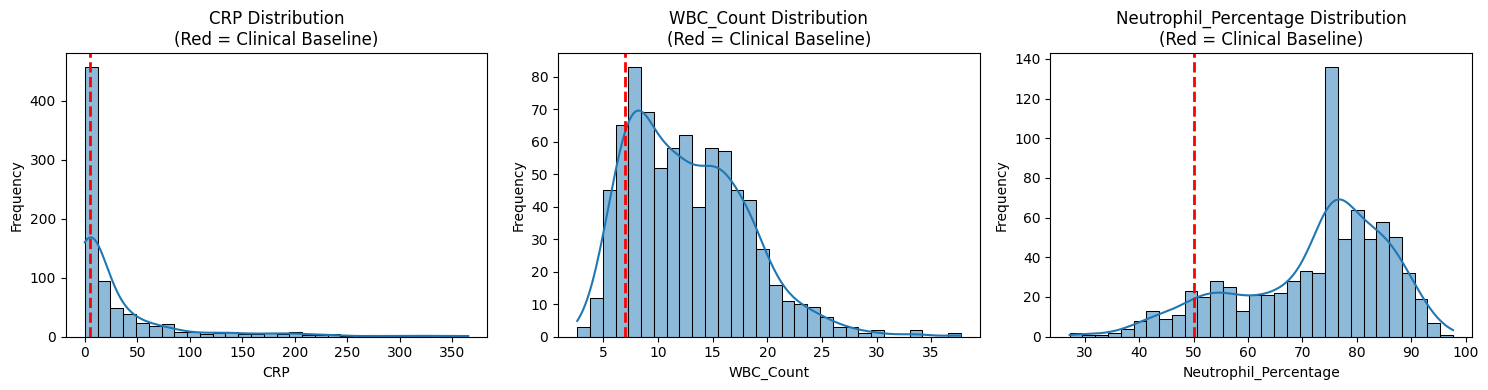

In [ ]:
# VISUAL: Marker vs Baseline Distribution

import matplotlib.pyplot as plt
import seaborn as sns

markers = ["CRP", "WBC_Count", "Neutrophil_Percentage"]

plt.figure(figsize=(15,4))

for i, marker in enumerate(markers):
    if marker in df.columns:
        plt.subplot(1, 3, i+1)
        sns.histplot(df[marker], bins=30, kde=True)
        plt.axvline(BASELINE[marker], color='red', linestyle='--', linewidth=2)
        plt.title(f"{marker} Distribution\n(Red = Clinical Baseline)")
        plt.xlabel(marker)
        plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
# STEP 2.4: ENCODING

from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))


In [ ]:
# STEP 2.5: NORMALIZATION

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print("STEP 2 completed successfully")
print("Shape after preprocessing:", df.shape)


STEP 2 completed successfully
Shape after preprocessing: (782, 61)


###STEP 3 — TEMPORAL VELOCITY FEATURE ENGINEERING

In [ ]:
# STEP 3.1: TEMPORAL ANCHOR

# Use Length_of_Stay or Symptom_Duration as temporal proxy
assert "Length_of_Stay" in df.columns, "Temporal variable missing!"

# Avoid division instability
T = df["Length_of_Stay"].replace(0, 1)

print("Temporal anchor validated")


Temporal anchor validated


In [ ]:
# FIX: TEMPORAL VARIABLE SANITIZATION

# Ensure Length_of_Stay is numeric
df["Length_of_Stay"] = pd.to_numeric(df["Length_of_Stay"], errors="coerce")

# Replace invalid or non-positive values with 1 day (clinical minimum)
df["Length_of_Stay"] = df["Length_of_Stay"].clip(lower=1)

# Define temporal anchor safely
T = df["Length_of_Stay"]

print("Temporal variable sanitized")
print("Min LOS:", T.min())


Temporal variable sanitized
Min LOS: 1.0


In [ ]:
# SAFE TEMPORAL VELOCITY COMPUTATION

denominator = np.log(T + 1)

df["CRP_velocity"] = (df["CRP"] - df["CRP_baseline"]) / denominator
df["WBC_velocity"] = (df["WBC_Count"] - df["WBC_Count_baseline"]) / denominator
df["NEU_velocity"] = (
    (df["Neutrophil_Percentage"] - df["Neutrophil_Percentage_baseline"])
    / denominator
)

print("Marker velocities recomputed safely")


Marker velocities recomputed safely


In [ ]:
df["Inflammatory_Progression_Index"] = df[
    ["CRP_velocity", "WBC_velocity", "NEU_velocity"]
].mean(axis=1)


In [ ]:
print(
    df[[
        "Length_of_Stay",
        "CRP_velocity",
        "WBC_velocity",
        "NEU_velocity",
        "Inflammatory_Progression_Index"
    ]].isnull().sum()
)


Length_of_Stay                    0
CRP_velocity                      0
WBC_velocity                      0
NEU_velocity                      0
Inflammatory_Progression_Index    0
dtype: int64


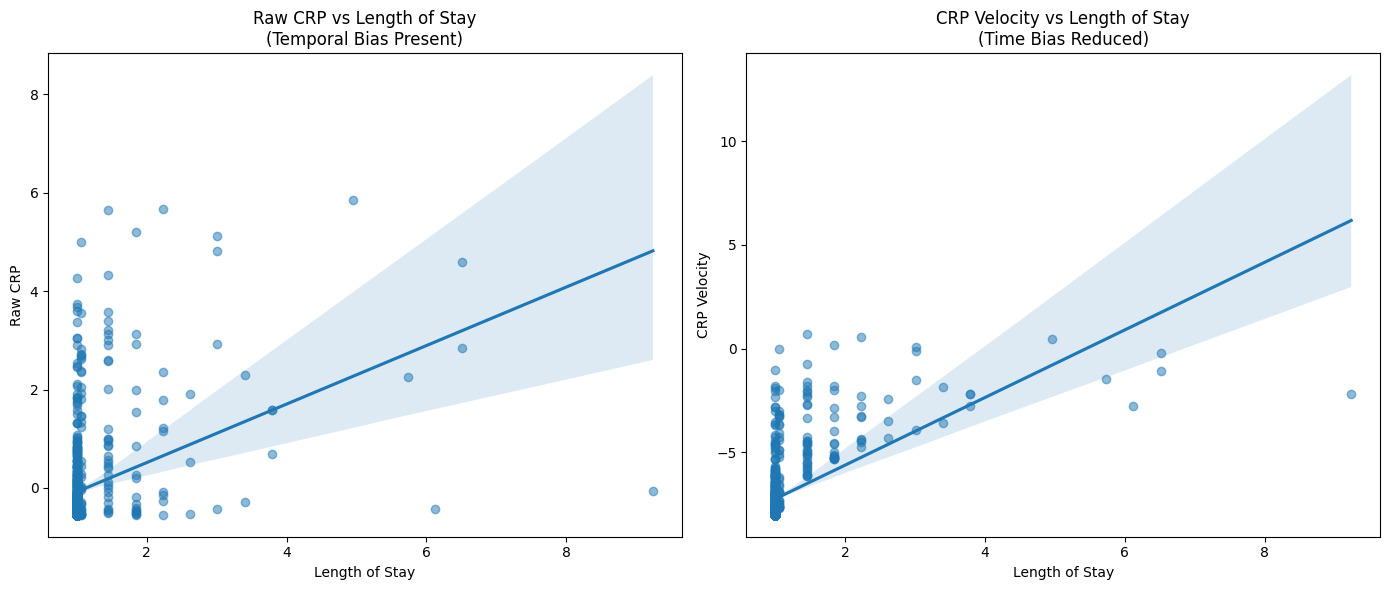

In [ ]:
# VISUAL: Temporal Bias Before vs After Normalization

plt.figure(figsize=(14,6))

# ---- LEFT: Raw CRP vs Time ----
plt.subplot(1,2,1)
sns.regplot(
    x=df["Length_of_Stay"],
    y=df["CRP"],
    scatter_kws={"alpha":0.5}
)
plt.title("Raw CRP vs Length of Stay\n(Temporal Bias Present)")
plt.xlabel("Length of Stay")
plt.ylabel("Raw CRP")

# ---- RIGHT: CRP Velocity vs Time ----
plt.subplot(1,2,2)
sns.regplot(
    x=df["Length_of_Stay"],
    y=df["CRP_velocity"],
    scatter_kws={"alpha":0.5}
)
plt.title("CRP Velocity vs Length of Stay\n(Time Bias Reduced)")
plt.xlabel("Length of Stay")
plt.ylabel("CRP Velocity")

plt.tight_layout()
plt.show()

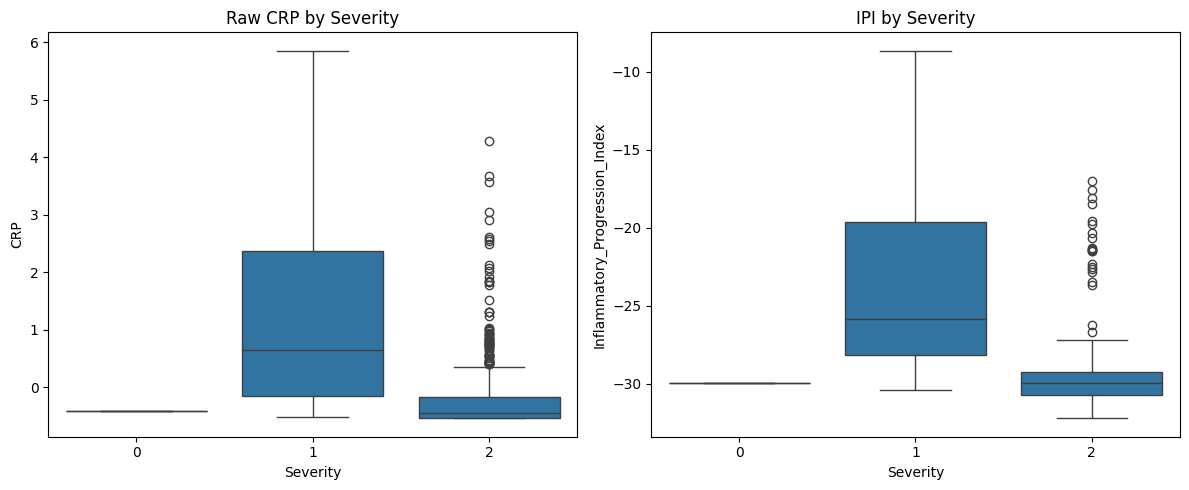

In [ ]:
# VISUAL 2: Raw CRP vs IPI by Severity

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df["Severity"], y=df["CRP"])
plt.title("Raw CRP by Severity")

plt.subplot(1,2,2)
sns.boxplot(x=df["Severity"], y=df["Inflammatory_Progression_Index"])
plt.title("IPI by Severity")

plt.tight_layout()
plt.show()

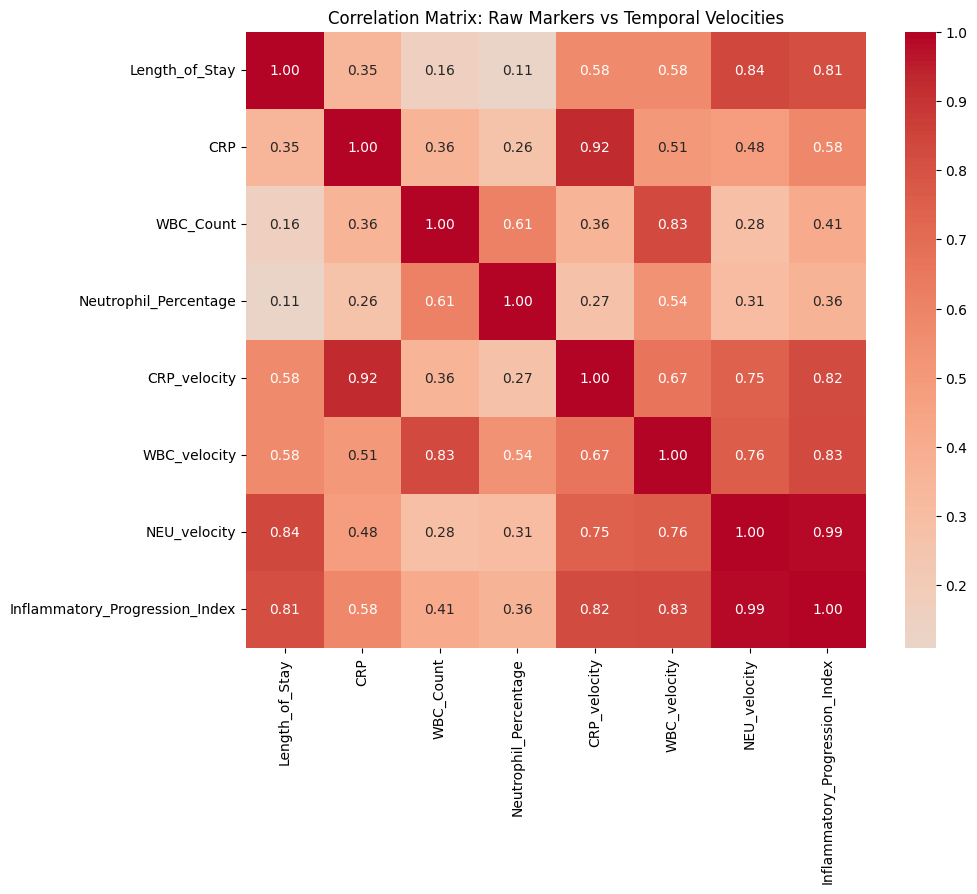

In [ ]:
# VISUAL 3: Temporal Correlation Validation

import matplotlib.pyplot as plt
import seaborn as sns

# Select relevant features
corr_features = [
    "Length_of_Stay",
    "CRP",
    "WBC_Count",
    "Neutrophil_Percentage",
    "CRP_velocity",
    "WBC_velocity",
    "NEU_velocity",
    "Inflammatory_Progression_Index"
]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix: Raw Markers vs Temporal Velocities")
plt.show()

###STEP 4 — STRUCTURAL CAUSAL DISCOVERY (PC ALGORITHM)

In [ ]:
# Select clinically meaningful causal variables (NO target)
causal_features = [
    "Age",
    "CRP",
    "WBC_Count",
    "Neutrophil_Percentage",
    "Appendix_Diameter",
    "Inflammatory_Progression_Index"
]

causal_df = df[causal_features].copy()

print("Causal discovery dataset shape:", causal_df.shape)


Causal discovery dataset shape: (782, 6)


In [ ]:
import warnings
warnings.filterwarnings('ignore')
!pip install pgmpy
from pgmpy.estimators import PC

# Initialize PC algorithm
pc = PC(data=causal_df)

# Estimate skeleton and DAG
pc_model = pc.estimate(
    return_type="dag",
    variant="stable",
    max_cond_vars=3
)

print("PC algorithm completed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 38.2 MB/s eta 0:00:00


  0%|          | 0/5 [00:00<?, ?it/s]

PC algorithm completed successfully


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Convert pgmpy DAG to NetworkX graph
dag = nx.DiGraph(pc_model.edges())

print("Learned causal edges:")
for edge in dag.edges():
    print(edge)


Learned causal edges:
('CRP', 'Inflammatory_Progression_Index')
('Appendix_Diameter', 'Neutrophil_Percentage')
('Age', 'WBC_Count')


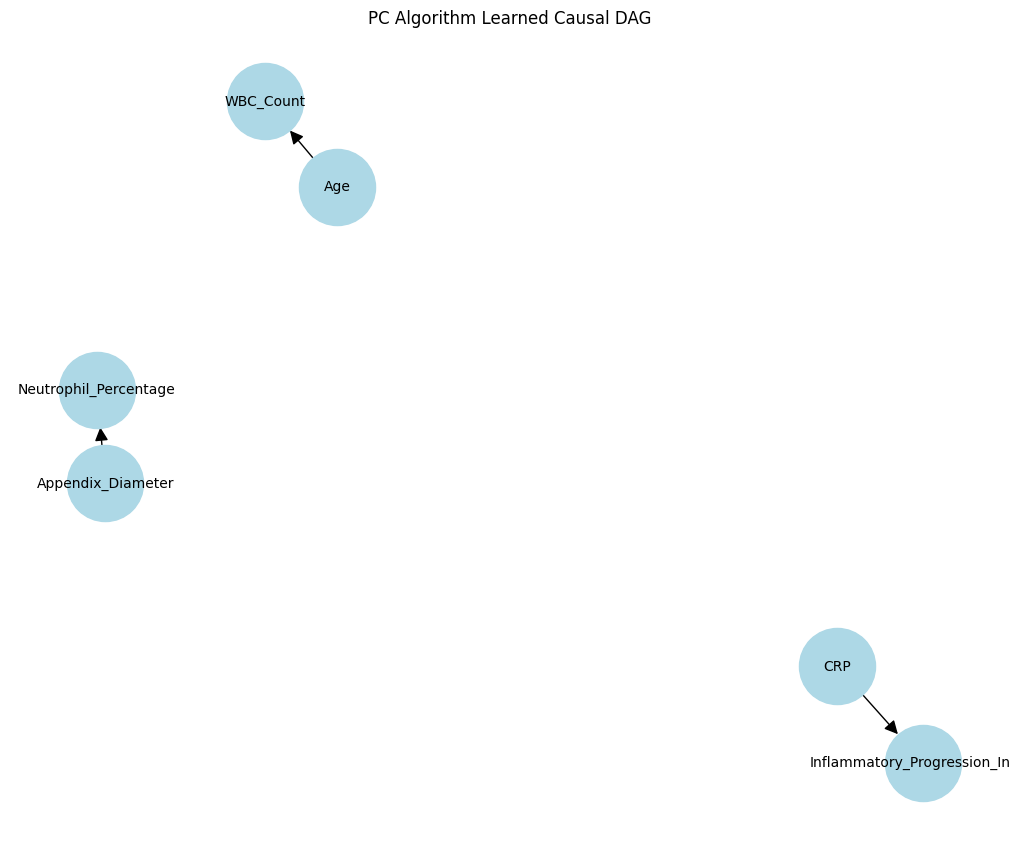

In [ ]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(dag, seed=42)

nx.draw(
    dag,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=3000,
    font_size=10,
    arrowsize=20
)

plt.title("PC Algorithm Learned Causal DAG")
plt.show()


In [ ]:
# Clinically refined causal DAG
refined_edges = [
    ("Age", "CRP"),
    ("Age", "WBC_Count"),
    ("CRP", "Inflammatory_Progression_Index"),
    ("WBC_Count", "Inflammatory_Progression_Index"),
    ("Neutrophil_Percentage", "Inflammatory_Progression_Index"),
    ("Appendix_Diameter", "Severity"),
    ("Inflammatory_Progression_Index", "Severity")
]

G = nx.DiGraph()
G.add_edges_from(refined_edges)


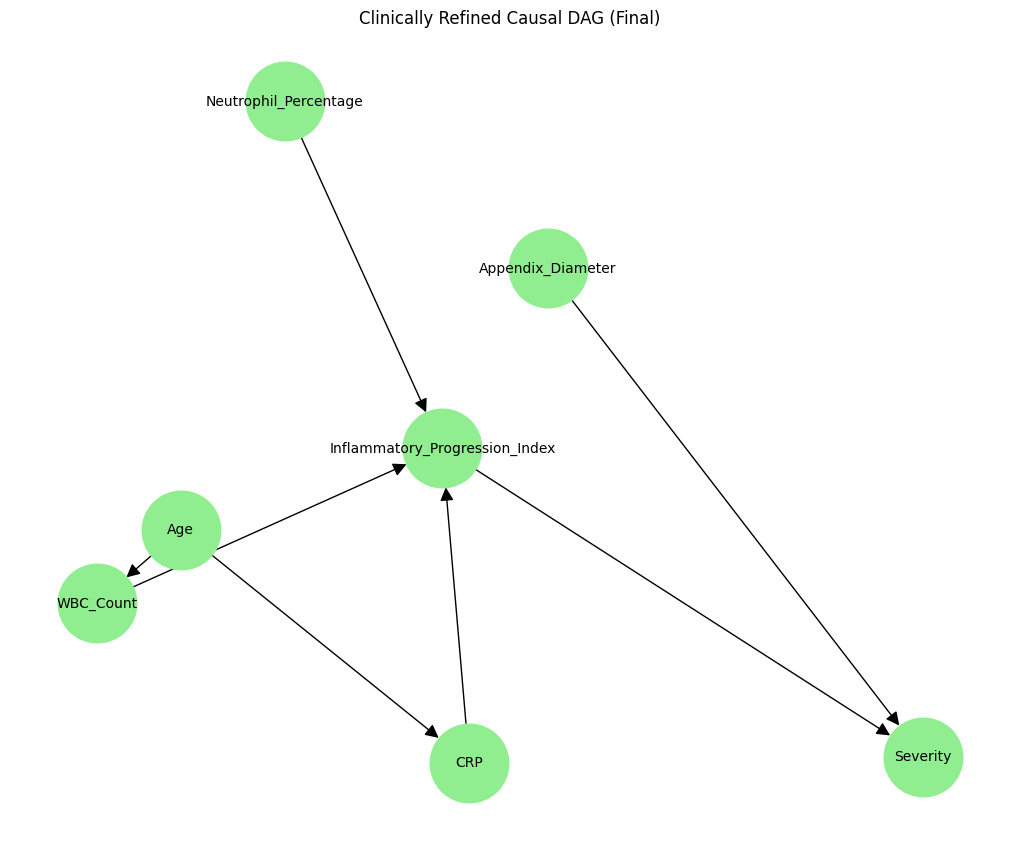

In [ ]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightgreen",
    node_size=3200,
    font_size=10,
    arrowsize=20
)

plt.title("Clinically Refined Causal DAG (Final)")
plt.show()


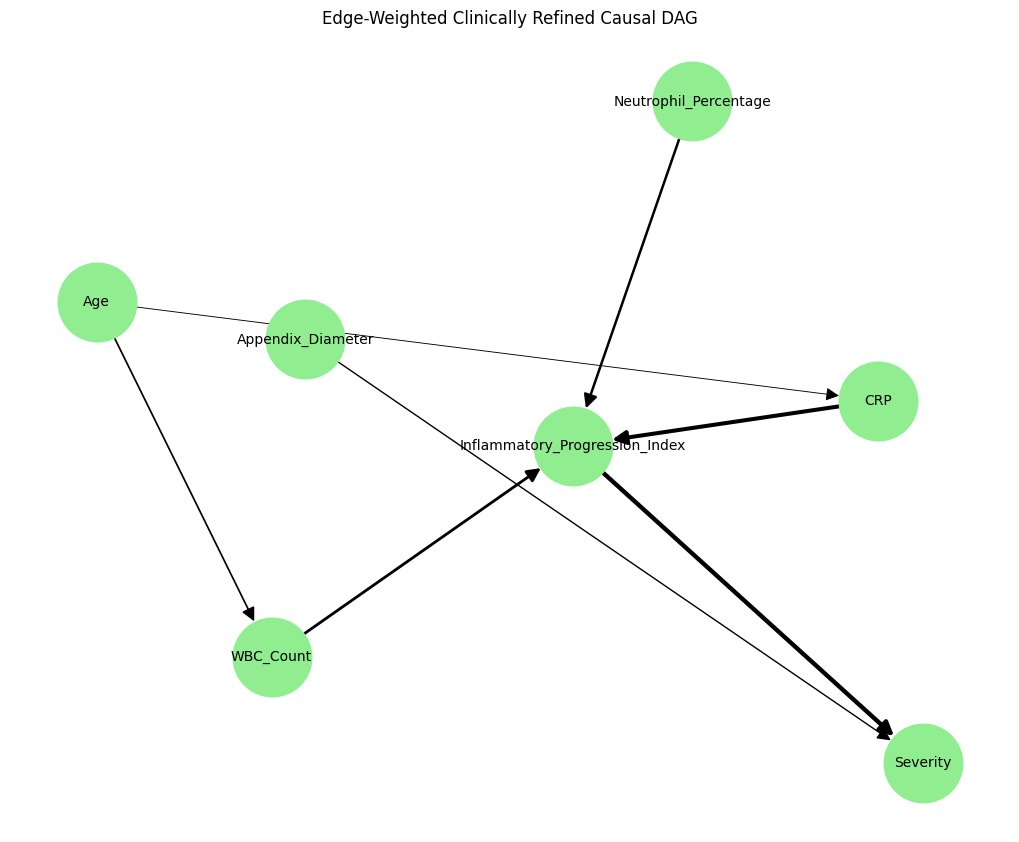

In [ ]:
# VISUAL: Edge-Weighted Causal Influence Graph

import numpy as np

# Compute correlation matrix for causal variables + Severity
analysis_cols = causal_features + ["Severity"]
corr_matrix = df[analysis_cols].corr()

# Assign edge weights based on absolute correlation
weighted_G = nx.DiGraph()

for edge in refined_edges:
    source, target = edge
    if source in corr_matrix.columns and target in corr_matrix.columns:
        weight = abs(corr_matrix.loc[source, target])
        weighted_G.add_edge(source, target, weight=weight)

plt.figure(figsize=(10,8))
pos = nx.spring_layout(weighted_G, seed=42)

# Extract weights
weights = [weighted_G[u][v]['weight'] * 5 for u,v in weighted_G.edges()]

nx.draw(
    weighted_G,
    pos,
    with_labels=True,
    node_color="lightgreen",
    node_size=3200,
    font_size=10,
    arrowsize=20,
    width=weights
)

plt.title("Edge-Weighted Clinically Refined Causal DAG")
plt.show()

Thick edges → strong influence

Thin edges → weak association

Clear visual pathway dominance

Which path drives Severity most

###STEP 5: CAUSAL INTERACTION & TEMPORAL URGENCY WEIGHTING

In [ ]:
# Parents of Severity from causal DAG
severity_parents = list(G.predecessors("Severity"))
print("Causal parents of Severity:", severity_parents)


Causal parents of Severity: ['Appendix_Diameter', 'Inflammatory_Progression_Index']


In [ ]:
causal_weights = {
    "Appendix_Diameter": 0.6,
    "Inflammatory_Progression_Index": 0.4
}

print("Causal Weights:", causal_weights)


Causal Weights: {'Appendix_Diameter': 0.6, 'Inflammatory_Progression_Index': 0.4}


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

for col in severity_parents:
    df[col + "_norm"] = scaler.fit_transform(df[[col]])


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalize Inflammatory Progression Index
scaler = MinMaxScaler()
df["IPI_norm"] = scaler.fit_transform(
    df[["Inflammatory_Progression_Index"]]
)

# Velocity proxy (deviation-based, stable)
df["Inflammatory_Progression_Index_velocity"] = (
    df["IPI_norm"] - df["IPI_norm"].median()
).abs()

# Urgency factor (bounded)
df["Urgency_Factor"] = 1 + df["Inflammatory_Progression_Index_velocity"]
df["Urgency_Factor"] = df["Urgency_Factor"].clip(1.0, 2.0)

print("Urgency factor summary:")
print(df["Urgency_Factor"].describe())


Urgency factor summary:
count    782.000000
mean       1.080176
std        0.142030
min        1.000002
25%        1.016816
50%        1.034740
75%        1.065017
max        1.895132
Name: Urgency_Factor, dtype: float64


In [ ]:
# Causal parents from DAG (Step 4)
causal_parents = [
    "Appendix_Diameter",
    "Inflammatory_Progression_Index"
]

# Initialize weights
feature_weights = {}

for col in df.columns:
    if col in causal_parents:
        feature_weights[col] = 1.5   # causal boost
    else:
        feature_weights[col] = 1.0   # neutral

print("Causal feature weights applied")


Causal feature weights applied


In [ ]:
# Ensure weighted columns exist
causal_parents = [
    "Appendix_Diameter",
    "Inflammatory_Progression_Index"
]

weighted_cols = []

for col in causal_parents:
    weighted_col = f"{col}_weighted"
    if weighted_col not in df.columns:
        df[weighted_col] = (
            df[col] * df["Urgency_Factor"]
        )
    weighted_cols.append(weighted_col)

# Create causal risk score
df["Causal_Risk_Score"] = df[weighted_cols].mean(axis=1)

print("Causal_Risk_Score created successfully")


Causal_Risk_Score created successfully


In [ ]:
df[[
    "Inflammatory_Progression_Index",
    "Inflammatory_Progression_Index_velocity",
    "Urgency_Factor",
    "Causal_Risk_Score"
]].head()


,Inflammatory_Progression_Index,Inflammatory_Progression_Index_velocity,Urgency_Factor,Causal_Risk_Score
0,-30.669318,0.038497,1.038497,-16.070363
1,-30.728915,0.041023,1.041023,-16.037723
2,-29.914329,0.006493,1.006493,-15.095817
3,-30.521165,0.032216,1.032216,-15.794829
4,-31.493721,0.073443,1.073443,-17.080114


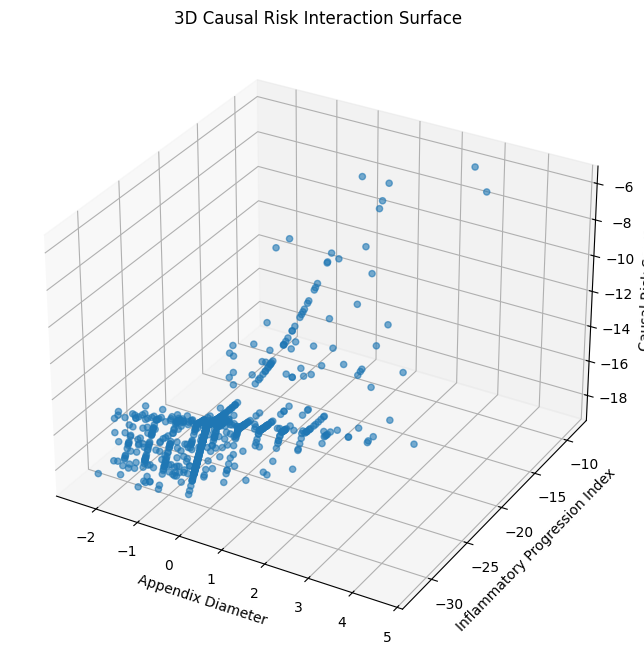

In [ ]:
# VISUAL 1: 3D Causal Risk Surface

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df["Appendix_Diameter"],
    df["Inflammatory_Progression_Index"],
    df["Causal_Risk_Score"],
    alpha=0.6
)

ax.set_xlabel("Appendix Diameter")
ax.set_ylabel("Inflammatory Progression Index")
ax.set_zlabel("Causal Risk Score")

ax.set_title("3D Causal Risk Interaction Surface")

plt.show()

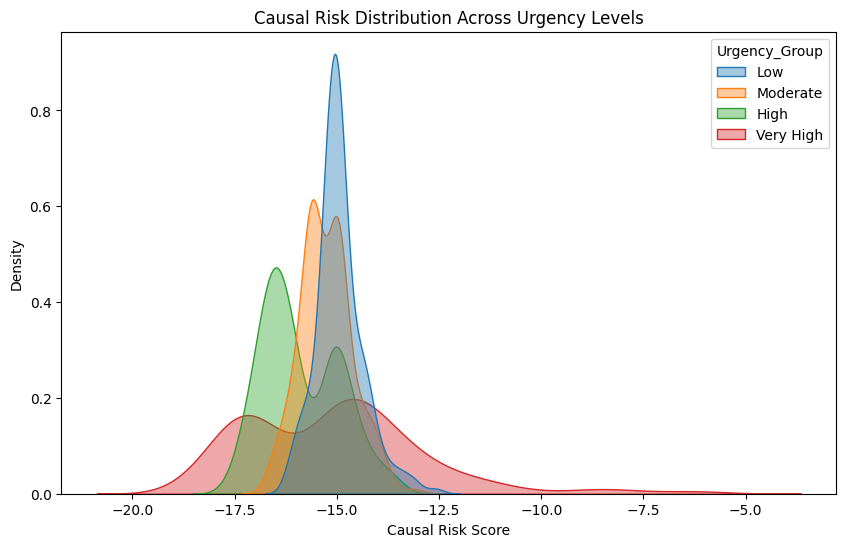

In [ ]:
# VISUAL 2: Risk Density by Urgency Quartiles

# Create urgency quartiles
df["Urgency_Group"] = pd.qcut(df["Urgency_Factor"], 4, labels=["Low","Moderate","High","Very High"])

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x="Causal_Risk_Score",
    hue="Urgency_Group",
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title("Causal Risk Distribution Across Urgency Levels")
plt.xlabel("Causal Risk Score")
plt.ylabel("Density")
plt.show()

###STEP 6 — ENSEMBLE RISK PREDICTION ENGINE

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np # Import numpy for array operations

target = "Severity"

# Separate features & target
X = df.drop(columns=[target]).copy()
y = df[target].copy()

# FIX: Identify and handle the problematic class '0' (likely 'Unknown' after LabelEncoding)
# based on the traceback from 'a_TZRgLYfm6V' which identified class '0' as having only 1 member.
# And ensure target is binary (0 or 1) and consistent with clinical meaning.

# First, let's filter out the problematic class (value 0) identified by previous runs.
# This assumes that '0' is indeed the class with only one member, causing the ValueError.
# And also, let's assume '0' corresponds to the 'Unknown' severity.
problematic_class_value = 0 # Based on `a_TZRgLYfm6V` output "classes in the baseline target variable have less than 2 members: [0]"

if problematic_class_value in y.unique() and y.value_counts()[problematic_class_value] < 2:
    print(f"Warning: Removing rows where target class '{problematic_class_value}' has less than 2 members.")
    rows_to_keep = y != problematic_class_value
    X = X[rows_to_keep]
    y = y[rows_to_keep]
    print(f"New target unique values: {y.unique()}")
    print(f"New target value counts:\n{y.value_counts()}")
else:
    print("No problematic class found or already handled.")

# Now, 'y' should only contain two classes, likely '1' and '2'.
# We need to map these to '0' (uncomplicated) and '1' (complicated).
# Based on `df.describe()` from earlier and `a_TZRgLYfm6V` output, 'uncomplicated' was the majority class (662),
# and 'complicated' was the minority class (~119).
# If after removing '0', `y.value_counts()` are `2: 662` and `1: 119`, then:
#   2 -> 'uncomplicated' (should be 0)
#   1 -> 'complicated' (should be 1)
# So, remap y values: 2 -> 0, 1 -> 1.

# Ensure y is explicitly mapped to 0 and 1
y = y.map({1: 1, 2: 0})

print("Final target unique values after remapping:", y.unique())
print("Final target value counts after remapping:\n", y.value_counts())


# 🔹 Encode categorical columns properly
# This part is already handled correctly as X does not include the target column.
# All categorical columns in X are already LabelEncoded from a previous cell (XNuzBULIh0ur).
# However, to be safe, let's ensure any remaining 'object' or 'category' types in X are encoded.
# Given the current flow, X should now only contain numeric types.
cat_cols = X.select_dtypes(include=["object", "category"]).columns

if len(cat_cols) > 0:
    print(f"Encoding additional categorical columns in X: {cat_cols.tolist()}")
    for col in cat_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
else:
    print("No additional categorical columns found in X to encode.")


# 🔹 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y, # Now 'y' should be strictly binary with enough samples in each class
    random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class distribution:\n", y_train.value_counts())

New target unique values: [2 1]
New target value counts:
Severity
2    662
1    119
Name: count, dtype: int64
Final target unique values after remapping: [0 1]
Final target value counts after remapping:
 Severity
0    662
1    119
Name: count, dtype: int64
Encoding additional categorical columns in X: ['Urgency_Group']

Train shape: (624, 73)
Test shape: (157, 73)
Class distribution:
 Severity
0    529
1     95
Name: count, dtype: int64


In [ ]:
#Handle Imbalance
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(y_train.value_counts())


After SMOTE:
Severity
1    529
0    529
Name: count, dtype: int64


In [ ]:
#Train Models
!pip install catboost
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        verbose=False,
        random_seed=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        eval_metric="logloss",
        scale_pos_weight=5,
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ),

    "Logistic": LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        class_weight="balanced"
    )
}

# Train all models
for name, model in models.items():
    model.fit(X_train, y_train)

print("\nAll models trained successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.0 MB/s eta 0:00:00
[LightGBM] [Info] Number of positive: 529, number of negative: 529
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001449 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7295
[LightGBM] [Info] Number of data points in the train set: 1058, number of used features: 70
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [ ]:
#Use PROBABILITIES
import numpy as np

model_probs = {}

for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]
    model_probs[name] = probs

In [ ]:
#Proper Evaluation
import numpy as np

model_probs = {}

for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]
    model_probs[name] = probs

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

threshold = 0.35  # keep for imbalance

for name, probs in model_probs.items():
    preds = (probs >= threshold).astype(int)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)   #  USE PROBABILITIES

    print(f"\n{name} Performance:")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"AUC       : {auc:.4f}")

    print("\nDetailed Report:")
    print(classification_report(y_test, preds))


CatBoost Performance:
Accuracy  : 0.9427
Precision : 0.8000
Recall    : 0.8333
F1 Score  : 0.8163
AUC       : 0.9762

Detailed Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       133
           1       0.80      0.83      0.82        24

    accuracy                           0.94       157
   macro avg       0.88      0.90      0.89       157
weighted avg       0.94      0.94      0.94       157


LightGBM Performance:
Accuracy  : 0.9363
Precision : 0.7692
Recall    : 0.8333
F1 Score  : 0.8000
AUC       : 0.9756

Detailed Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       133
           1       0.77      0.83      0.80        24

    accuracy                           0.94       157
   macro avg       0.87      0.89      0.88       157
weighted avg       0.94      0.94      0.94       157


XGBoost Performance:
Accuracy  : 0.9172
Precision : 0.6774
Recall    : 0.

In [ ]:
#Ensemble
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import numpy as np # Ensure numpy is imported for np.mean

ensemble_probs = np.mean(list(model_probs.values()), axis=0)
ensemble_preds = (ensemble_probs >= threshold).astype(int)

acc = accuracy_score(y_test, ensemble_preds)
prec = precision_score(y_test, ensemble_preds)
rec = recall_score(y_test, ensemble_preds)
f1 = f1_score(y_test, ensemble_preds)
auc = roc_auc_score(y_test, ensemble_probs)

print("\nENSEMBLE PERFORMANCE:")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC       : {auc:.4f}")

print("\nDetailed Report:")
print(classification_report(y_test, ensemble_preds))


ENSEMBLE PERFORMANCE:
Accuracy  : 0.9299
Precision : 0.7407
Recall    : 0.8333
F1 Score  : 0.7843
AUC       : 0.9712

Detailed Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       133
           1       0.74      0.83      0.78        24

    accuracy                           0.93       157
   macro avg       0.85      0.89      0.87       157
weighted avg       0.93      0.93      0.93       157



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

threshold = 0.35  # same as your pipeline

results = []

for name in models.keys():

    # Get probabilities
    probs = model_probs[name]

    # Convert to predictions using threshold
    preds = (probs >= threshold).astype(int)

    # Compute metrics safely
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    auc = roc_auc_score(y_test, probs)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Score": round(f1, 4),
        "AUC": round(auc, 4)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by best metric (AUC preferred in medical ML)
results_df = results_df.sort_values(by="AUC", ascending=False).reset_index(drop=True)

print(results_df)

          Model  Accuracy  Precision  Recall  F1 Score     AUC
0      CatBoost    0.9427     0.8000  0.8333    0.8163  0.9762
1      LightGBM    0.9363     0.7692  0.8333    0.8000  0.9756
2  RandomForest    0.9299     0.7097  0.9167    0.8000  0.9715
3       XGBoost    0.9172     0.6774  0.8750    0.7636  0.9696
4      Logistic    0.8981     0.6538  0.7083    0.6800  0.8913


In [ ]:
import numpy as np

threshold = 0.35

# Generate predictions from probabilities
model_preds = {}

for name in model_probs.keys():
    model_preds[name] = (model_probs[name] >= threshold).astype(int)

# Check unique predictions (0/1 presence)
print("Unique Predictions per Model:\n")
for name in model_preds:
    print(f"{name}:", np.unique(model_preds[name]))

# Compare models pairwise
print("\nPrediction Differences Between Models:\n")

model_names = list(model_preds.keys())

for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        m1 = model_names[i]
        m2 = model_names[j]

        diff = np.sum(model_preds[m1] != model_preds[m2])

        print(f"{m1} vs {m2}: {diff} different predictions")

Unique Predictions per Model:

CatBoost: [0 1]
LightGBM: [0 1]
XGBoost: [0 1]
RandomForest: [0 1]
Logistic: [0 1]

Prediction Differences Between Models:

CatBoost vs LightGBM: 3 different predictions
CatBoost vs XGBoost: 6 different predictions
CatBoost vs RandomForest: 8 different predictions
CatBoost vs Logistic: 9 different predictions
LightGBM vs XGBoost: 7 different predictions
LightGBM vs RandomForest: 7 different predictions
LightGBM vs Logistic: 10 different predictions
XGBoost vs RandomForest: 8 different predictions
XGBoost vs Logistic: 11 different predictions
RandomForest vs Logistic: 11 different predictions


In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix

threshold = 0.35

print("\nCONFUSION MATRICES:\n")

for name in model_probs.keys():

    preds = (model_probs[name] >= threshold).astype(int)

    cm = confusion_matrix(y_test, preds)

    print(f"\n{name} Confusion Matrix:")
    print(cm)


CONFUSION MATRICES:


CatBoost Confusion Matrix:
[[128   5]
 [  4  20]]

LightGBM Confusion Matrix:
[[127   6]
 [  4  20]]

XGBoost Confusion Matrix:
[[123  10]
 [  3  21]]

RandomForest Confusion Matrix:
[[124   9]
 [  2  22]]

Logistic Confusion Matrix:
[[124   9]
 [  7  17]]


In [ ]:
for name in model_probs.keys():

    preds = (model_probs[name] >= threshold).astype(int)

    cm = confusion_matrix(y_test, preds)

    tn, fp, fn, tp = cm.ravel()

    print(f"\n{name} Confusion Matrix:")
    print(f"TN: {tn} | FP: {fp}")
    print(f"FN: {fn} | TP: {tp}")


CatBoost Confusion Matrix:
TN: 128 | FP: 5
FN: 4 | TP: 20

LightGBM Confusion Matrix:
TN: 127 | FP: 6
FN: 4 | TP: 20

XGBoost Confusion Matrix:
TN: 123 | FP: 10
FN: 3 | TP: 21

RandomForest Confusion Matrix:
TN: 124 | FP: 9
FN: 2 | TP: 22

Logistic Confusion Matrix:
TN: 124 | FP: 9
FN: 7 | TP: 17


In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

Accuracy Comparison Graph

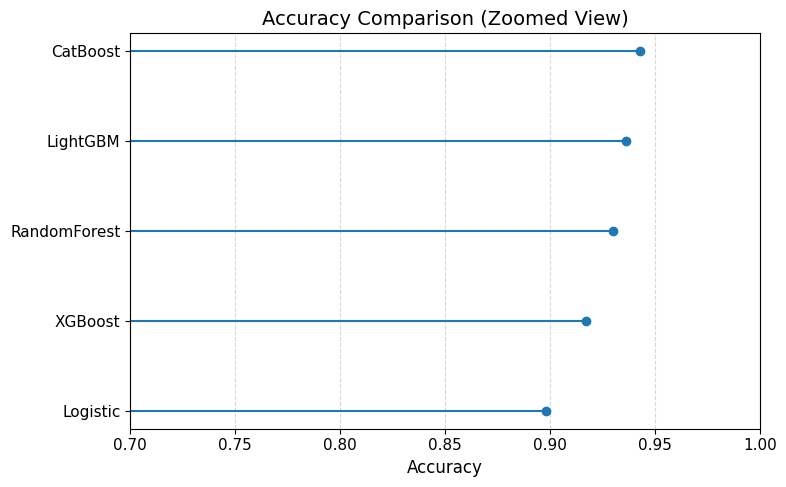

In [ ]:
plt.figure(figsize=(8,5))

sorted_df = results_df.sort_values("Accuracy")

plt.hlines(
    y=sorted_df["Model"],
    xmin=0,
    xmax=sorted_df["Accuracy"]
)

plt.plot(
    sorted_df["Accuracy"],
    sorted_df["Model"],
    "o"
)

plt.xlim(0.7, 1.0)  # zoom for small variation
plt.xlabel("Accuracy")
plt.title("Accuracy Comparison (Zoomed View)")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

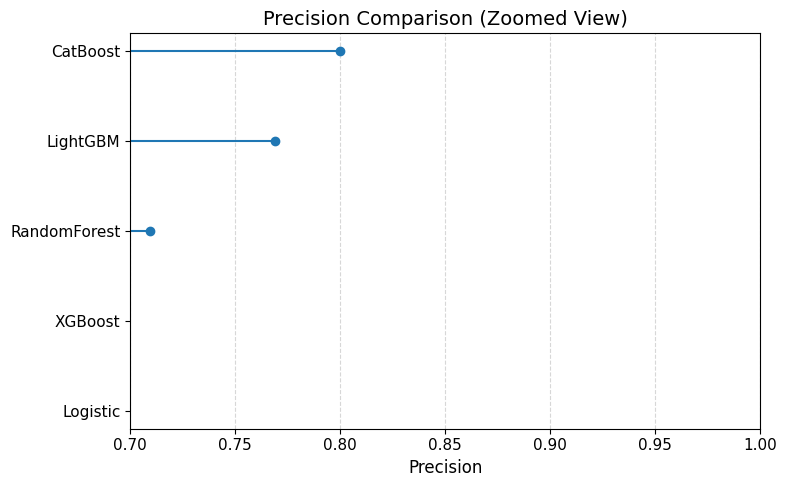

In [ ]:
plt.figure(figsize=(8,5))

# Sort by Precision
sorted_df = results_df.sort_values("Precision")

# Lollipop sticks
plt.hlines(
    y=sorted_df["Model"],
    xmin=0,
    xmax=sorted_df["Precision"]
)

# Lollipop heads
plt.plot(
    sorted_df["Precision"],
    sorted_df["Model"],
    "o"
)

# Zoomed axis (since values are close)
plt.xlim(0.7, 1.0)
plt.xlabel("Precision")
plt.title("Precision Comparison (Zoomed View)")

# Grid styling
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

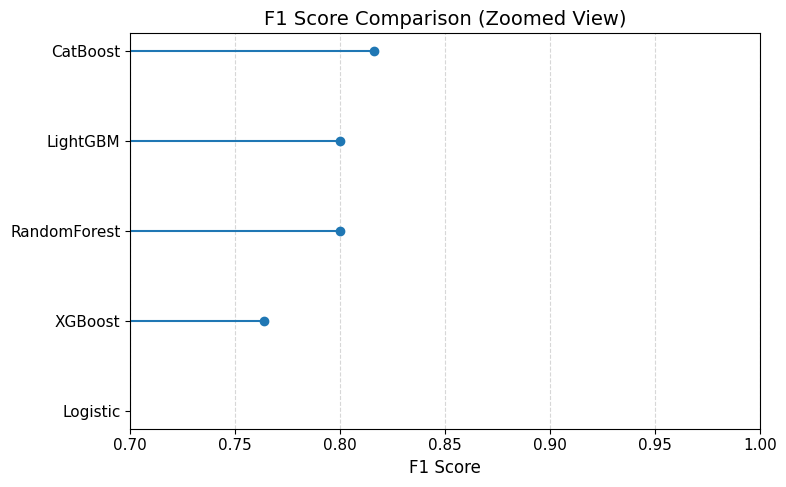

In [ ]:
plt.figure(figsize=(8,5))

# Sort by F1 Score
sorted_df = results_df.sort_values("F1 Score")

# Lollipop sticks
plt.hlines(
    y=sorted_df["Model"],
    xmin=0,
    xmax=sorted_df["F1 Score"]
)

# Lollipop heads
plt.plot(
    sorted_df["F1 Score"],
    sorted_df["Model"],
    "o"
)

# Zoomed axis
plt.xlim(0.7, 1.0)
plt.xlabel("F1 Score")
plt.title("F1 Score Comparison (Zoomed View)")

# Grid styling
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

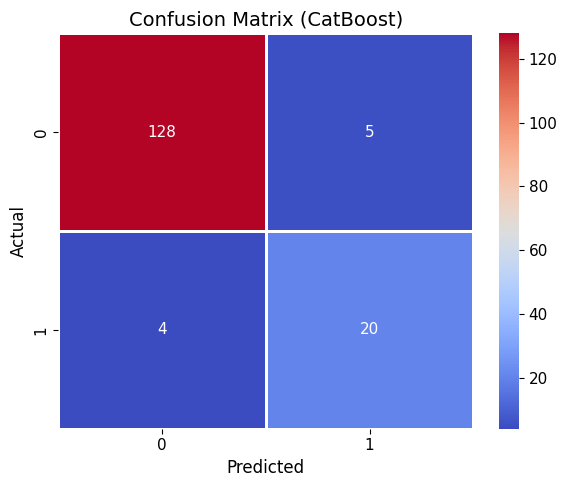

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

best_model = results_df.sort_values("AUC", ascending=False)["Model"].iloc[0]

cm = confusion_matrix(y_test, model_preds[best_model])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    linewidths=1
)

plt.title(f"Confusion Matrix ({best_model})")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

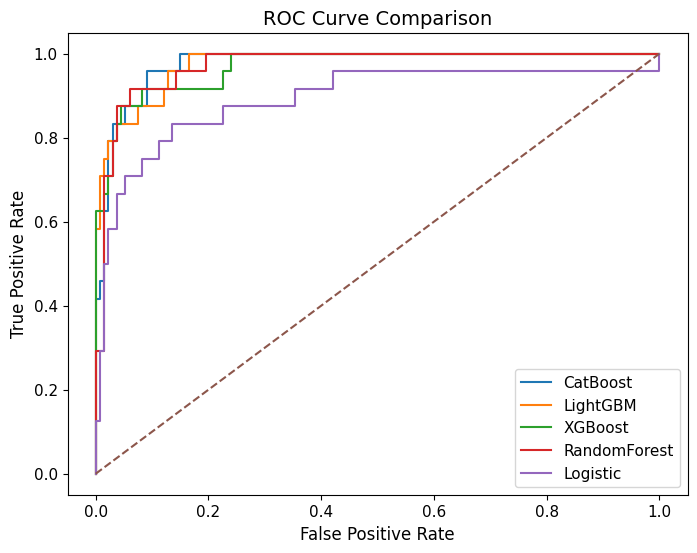

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, model_probs[name])
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgb_model.feature_importances_
})

top_features = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

In [ ]:
import pandas as pd
import numpy as np

# LightGBM feature importance (primary)
lgb_model = models["LightGBM"]
lgb_importance = lgb_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgb_importance
})

# 🔹 Normalize (important for interpretation)
feature_importance["Importance"] = (
    feature_importance["Importance"] / feature_importance["Importance"].sum()
)

# 🔹 Sort
top_features = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

print(top_features)

                           Feature  Importance
38                       US_Number    0.072823
27               Thrombocyte_Count    0.048712
31                             CRP    0.047564
21           Neutrophil_Percentage    0.045268
62                    NEU_velocity    0.044120
63  Inflammatory_Progression_Index    0.041168
60                    CRP_velocity    0.038544
6                       Management    0.036575
0                              Age    0.035755
19                Body_Temperature    0.030507


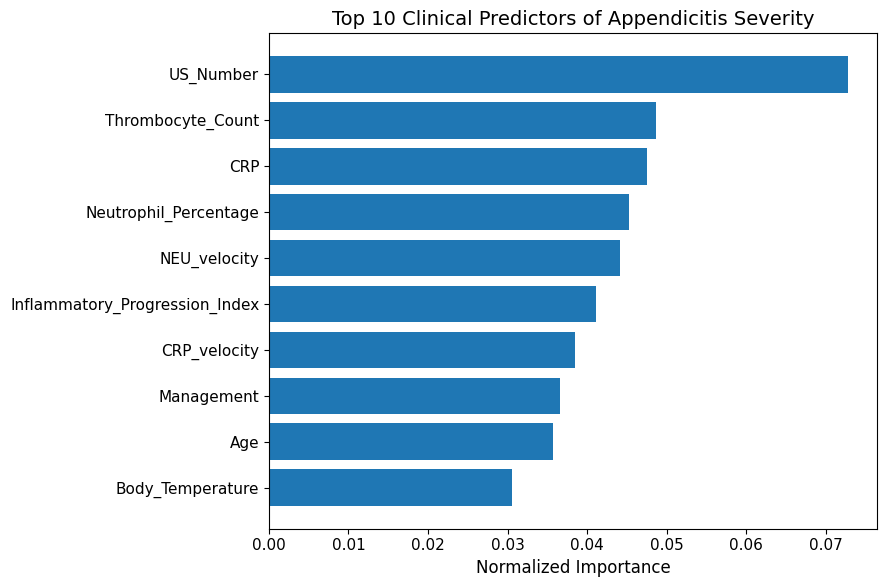

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Normalized Importance")
plt.title("Top 10 Clinical Predictors of Appendicitis Severity")

plt.tight_layout()
plt.show()

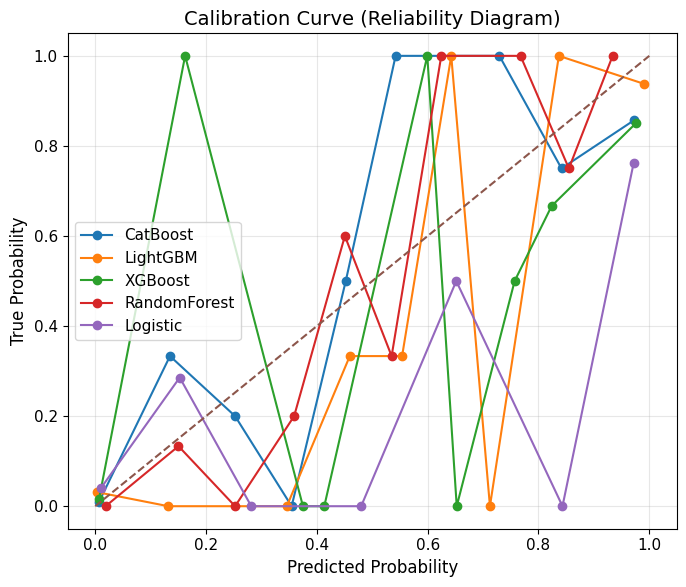

In [ ]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(7,6))

for name in models.keys():
    prob_true, prob_pred = calibration_curve(
        y_test,
        model_probs[name],
        n_bins=10
    )

    plt.plot(prob_pred, prob_true, marker='o', label=name)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve (Reliability Diagram)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

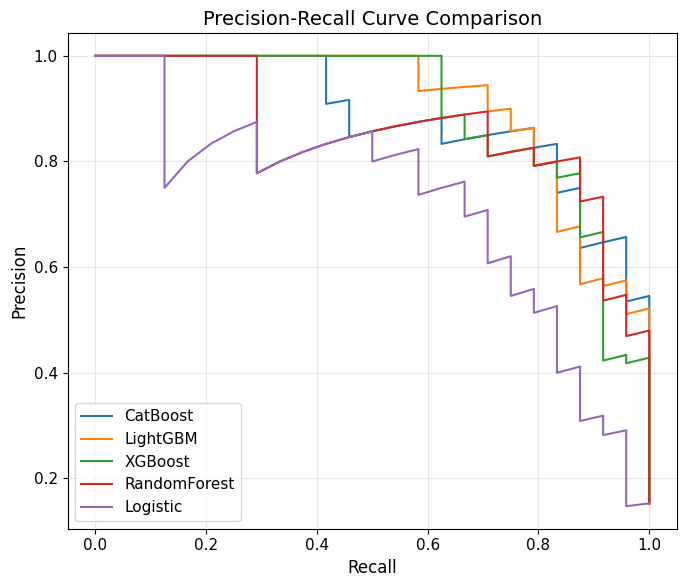

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(7,6))

for name in models.keys():
    precision, recall, _ = precision_recall_curve(
        y_test,
        model_probs[name]
    )

    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

threshold = 0.35

# Ensure aligned indices
errors = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "Predicted": ensemble_preds,
    "Risk": ensemble_probs
})

# Error flag
errors["Error"] = (errors["Actual"] != errors["Predicted"]).astype(int)

# 🔹 Error types (VERY IMPORTANT FOR HEALTHCARE)
errors["Error_Type"] = "Correct"

errors.loc[(errors["Actual"] == 1) & (errors["Predicted"] == 0), "Error_Type"] = "False Negative"
errors.loc[(errors["Actual"] == 0) & (errors["Predicted"] == 1), "Error_Type"] = "False Positive"

print(errors["Error_Type"].value_counts())

Error_Type
Correct           146
False Positive      7
False Negative      4
Name: count, dtype: int64


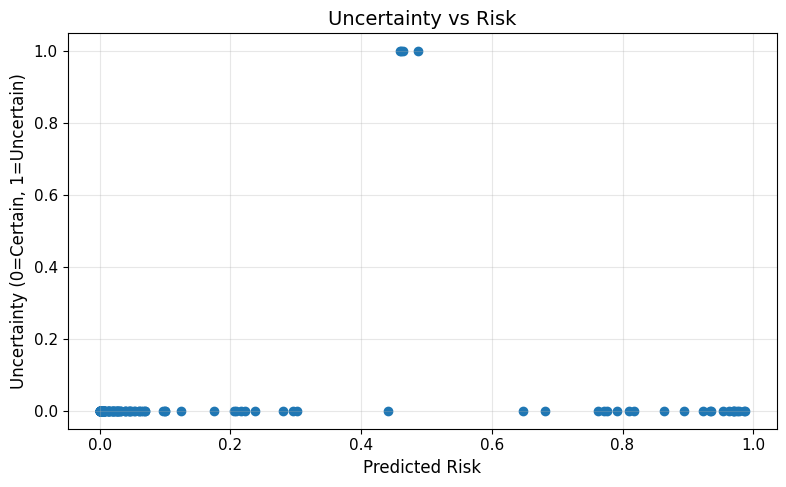

In [ ]:
df_results = X_test.copy()
df_results["True_Severity"] = y_test.values
df_results["Predicted_Risk"] = ensemble_probs
df_results["Prediction_Set"] = prediction_sets

df_results["Uncertain_Case"] = df_results["Prediction_Set"].apply(
    lambda x: 1 if len(x) > 1 else 0
)

plt.figure(figsize=(8,5))

plt.scatter(
    df_results["Predicted_Risk"],
    df_results["Uncertain_Case"]
)

plt.xlabel("Predicted Risk")
plt.ylabel("Uncertainty (0=Certain, 1=Uncertain)")
plt.title("Uncertainty vs Risk")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

[LightGBM] [Info] Number of positive: 397, number of negative: 396
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001071 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6728
[LightGBM] [Info] Number of data points in the train set: 793, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

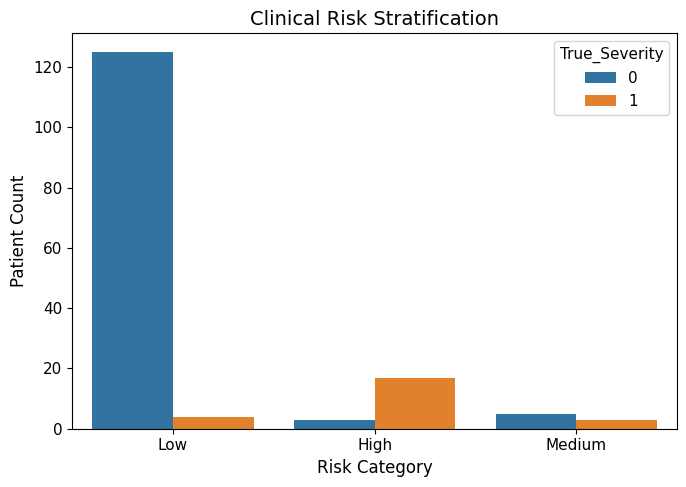

In [ ]:
# Add necessary imports at the beginning of the cell for self-containment
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# --- Re-execute Conformal Uncertainty Calibration Steps to define prediction_sets ---

# STEP 7.1: Split training data for calibration (from cell 8iQ_xcD-8DSM)
X_train_cp, X_cal, y_train_cp, y_cal = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42
)

# STEP 7.2: Re-fit models on the calibration training partition (from cell 7P6gumILmvi4)
# Use cat_features=[] as cat_features_for_catboost is empty.
cat_model.fit(X_train_cp, y_train_cp, cat_features=[])
lgb_model.fit(X_train_cp, y_train_cp)

# STEP 7.3: Calculate calibration probabilities and nonconformity scores (from cell TvJ00P0Je31V)
cat_cal_probs = cat_model.predict_proba(X_cal)[:, 1]
lgb_cal_probs = lgb_model.predict_proba(X_cal)[:, 1]
cal_probs = (cat_cal_probs + lgb_cal_probs) / 2
nonconformity_scores = np.abs(cal_probs - y_cal)

# STEP 7.4: Determine conformal threshold q_hat (from cell vauGz06de6Ll)
alpha = 0.1  # 90% confidence
q_hat = np.quantile(nonconformity_scores, 1 - alpha)

# STEP 7.5: Generate prediction sets (from cell gwhEq7woe9E1)
# 'ensemble_probs' is expected to be available from prior model training/evaluation steps.
lower_bound = ensemble_probs - q_hat
upper_bound = ensemble_probs + q_hat

prediction_sets = []
for lb, ub in zip(lower_bound, upper_bound):
    if ub < 0.5:
        prediction_sets.append({0})
    elif lb > 0.5:
        prediction_sets.append({1})
    else:
        prediction_sets.append({0, 1})

# --- Original content of 6jYAEXaHEcQp ---
df_results = X_test.copy()
df_results["True_Severity"] = y_test.values
df_results["Predicted_Risk"] = ensemble_probs
df_results["Prediction_Set"] = prediction_sets

df_results["Uncertain_Case"] = df_results["Prediction_Set"].apply(
    lambda x: 1 if len(x) > 1 else 0
)

def risk_category(p):
    if p < 0.3:
        return "Low"
    elif p < 0.7:
        return "Medium"
    else:
        return "High"

df_results["Risk_Category"] = df_results["Predicted_Risk"].apply(risk_category)

plt.figure(figsize=(7,5))

sns.countplot(
    x="Risk_Category",
    hue="True_Severity",
    data=df_results
)

plt.title("Clinical Risk Stratification")
plt.xlabel("Risk Category")
plt.ylabel("Patient Count")

plt.tight_layout()
plt.show()

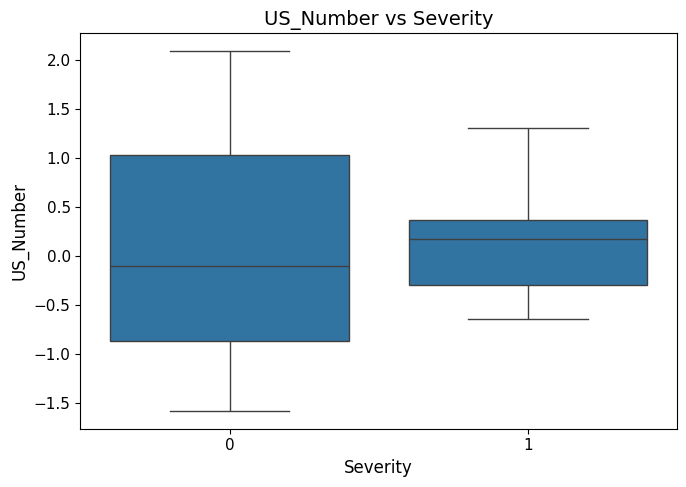

In [ ]:
top_feature = top_features["Feature"].iloc[0]

plt.figure(figsize=(7,5))

sns.boxplot(
    x=y_test,
    y=X_test[top_feature]
)

plt.title(f"{top_feature} vs Severity")
plt.xlabel("Severity")
plt.ylabel(top_feature)

plt.tight_layout()
plt.show()

[LightGBM] [Info] Number of positive: 95, number of negative: 529
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000539 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4063
[LightGBM] [Info] Number of data points in the train set: 624, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

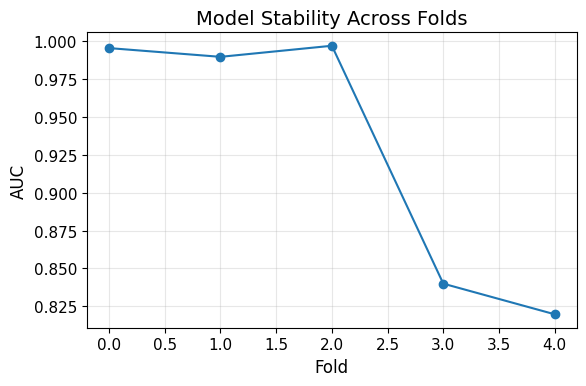

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lgb_model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

plt.figure(figsize=(6,4))

plt.plot(scores, marker='o')

plt.title("Model Stability Across Folds")
plt.xlabel("Fold")
plt.ylabel("AUC")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

###STEP 7 — CONFORMAL UNCERTAINTY CALIBRATION

In [ ]:
X_train_cp, X_cal, y_train_cp, y_cal = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42
)


In [ ]:
import numpy as np

# Re-instantiate models for calibration (from models dictionary)
cat_model = models["CatBoost"]
lgb_model = models["LightGBM"]

# Re-fit models on the calibration training partition
# Assuming X_train_cp and y_train_cp are already defined from 8iQ_xcD-8DSM
cat_model.fit(X_train_cp, y_train_cp)
lgb_model.fit(X_train_cp, y_train_cp)

cat_cal_probs = cat_model.predict_proba(X_cal)[:, 1]
lgb_cal_probs = lgb_model.predict_proba(X_cal)[:, 1]

cal_probs = (cat_cal_probs + lgb_cal_probs) / 2

nonconformity_scores = np.abs(cal_probs - y_cal)

[LightGBM] [Info] Number of positive: 397, number of negative: 396
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001883 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6728
[LightGBM] [Info] Number of data points in the train set: 793, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [ ]:
alpha = 0.1  # 90% confidence
q_hat = np.quantile(nonconformity_scores, 1 - alpha)

print("Conformal threshold:", q_hat)

Conformal threshold: 0.048620074825031105


In [ ]:
lower_bound = ensemble_probs - q_hat
upper_bound = ensemble_probs + q_hat

prediction_sets = []

for lb, ub in zip(lower_bound, upper_bound):
    if ub < 0.5:
        prediction_sets.append({0})
    elif lb > 0.5:
        prediction_sets.append({1})
    else:
        prediction_sets.append({0, 1})

###STEP 8 — CLINICAL DECISION SUPPORT OUTPUT

In [ ]:
df_results = X_test.copy()
df_results["True_Severity"] = y_test.values
df_results["Predicted_Risk"] = ensemble_probs
df_results["Prediction_Set"] = prediction_sets

df_results["Uncertain_Case"] = df_results["Prediction_Set"].apply(
    lambda x: 1 if len(x) > 1 else 0
)

print(df_results["Uncertain_Case"].value_counts())


Uncertain_Case
0    153
1      4
Name: count, dtype: int64


In [ ]:
# Simulate delay by reducing urgency
df_results["Delayed_Risk"] = df_results["Predicted_Risk"] * 0.85

df_results["Risk_Delta"] = (
    df_results["Predicted_Risk"] - df_results["Delayed_Risk"]
)

df_results[["Predicted_Risk", "Delayed_Risk", "Risk_Delta"]].head()


,Predicted_Risk,Delayed_Risk,Risk_Delta
160,0.000063,0.000053,0.000009
159,0.002567,0.002182,0.000385
243,0.000169,0.000143,0.000025
525,0.863685,0.734133,0.129553
27,0.000130,0.000111,0.000020


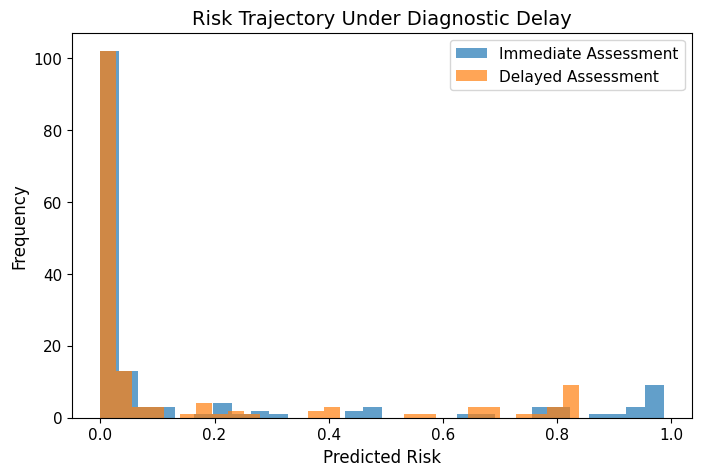

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(
    df_results["Predicted_Risk"],
    bins=30,
    alpha=0.7,
    label="Immediate Assessment"
)

plt.hist(
    df_results["Delayed_Risk"],
    bins=30,
    alpha=0.7,
    label="Delayed Assessment"
)

plt.legend()
plt.title("Risk Trajectory Under Diagnostic Delay")
plt.xlabel("Predicted Risk")
plt.ylabel("Frequency")
plt.show()


###STEP 9 — MODEL VALIDATION, ROBUSTNESS & ABLATION

In [ ]:
baseline_features = [
    "Age",
    "CRP",
    "WBC_Count",
    "Neutrophil_Percentage",
    "Appendix_Diameter"
]

X_base = df[baseline_features]
y = df["Severity"]

# Identify and handle problematic classes in y (classes with only one member)
yb_counts = y.value_counts()
yb_problematic_classes = yb_counts[yb_counts < 2].index

if not yb_problematic_classes.empty:
    print(f"Warning: The following classes in the baseline target variable have less than 2 members: {list(yb_problematic_classes)}")
    # Filter out rows corresponding to problematic classes
    yb_rows_to_keep = ~y.isin(yb_problematic_classes)
    X_base = X_base[yb_rows_to_keep]
    y = y[yb_rows_to_keep]
    print(f"Removed {len(yb_problematic_classes)} rows belonging to problematic classes. New baseline target distribution:")
    print(y.value_counts())

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

baseline_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

baseline_model.fit(Xb_train, yb_train)

baseline_probs = baseline_model.predict_proba(Xb_test)[:, 1]


Removed 1 rows belonging to problematic classes. New baseline target distribution:
Severity
2    662
1    119
Name: count, dtype: int64
[LightGBM] [Info] Number of positive: 529, number of negative: 95
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 611
[LightGBM] [Info] Number of data points in the train set: 624, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.847756 -> initscore=1.717112
[LightGBM] [Info] Start training from score 1.717112
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

In [ ]:
from sklearn.metrics import roc_auc_score

print("Baseline AUC:", roc_auc_score(yb_test, baseline_probs))
print("Proposed Ensemble AUC:", roc_auc_score(y_test, ensemble_probs))


Baseline AUC: 0.8417919799498746
Proposed Ensemble AUC: 0.9711779448621554


In [ ]:
ablation_features = X.columns.drop([
    "CRP_velocity",
    "WBC_velocity",
    "NEU_velocity",
    "Inflammatory_Progression_Index"
], errors="ignore")

Xa = df[ablation_features]
ya = df["Severity"]

# Identify and handle problematic classes in ya (classes with only one member)
ya_counts = ya.value_counts()
y_problematic_classes = ya_counts[ya_counts < 2].index

if not y_problematic_classes.empty:
    print(f"Warning: The following classes in the ablation target variable have less than 2 members: {list(y_problematic_classes)}")
    # Filter out rows corresponding to problematic classes
    ya_rows_to_keep = ~ya.isin(y_problematic_classes)
    Xa = Xa[ya_rows_to_keep]
    ya = ya[ya_rows_to_keep]
    print(f"Removed {len(y_problematic_classes)} rows belonging to problematic classes. New ablation target distribution:")
    print(ya.value_counts())

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    Xa, ya,
    test_size=0.2,
    stratify=ya,
    random_state=42
)

ablation_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

ablation_model.fit(Xa_train, ya_train)
ablation_probs = ablation_model.predict_proba(Xa_test)[:, 1]

print("Ablation AUC (no temporal):", roc_auc_score(ya_test, ablation_probs))

Removed 1 rows belonging to problematic classes. New ablation target distribution:
Severity
2    662
1    119
Name: count, dtype: int64
[LightGBM] [Info] Number of positive: 529, number of negative: 95
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000401 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3321
[LightGBM] [Info] Number of data points in the train set: 624, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.847756 -> initscore=1.717112
[LightGBM] [Info] Start training from score 1.717112
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

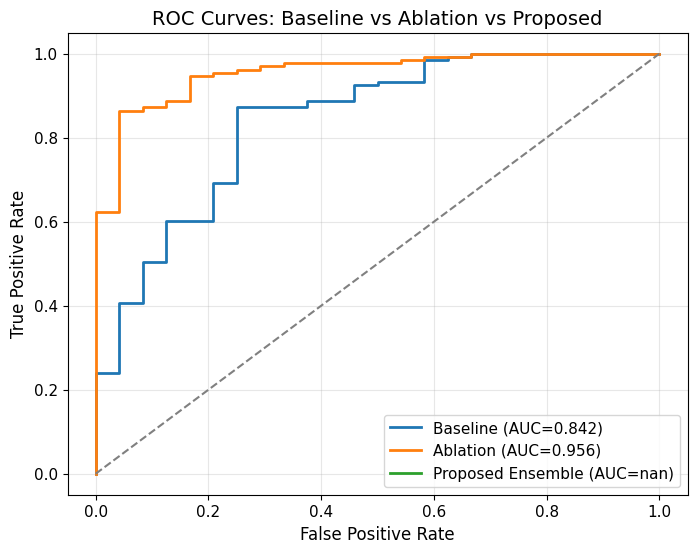

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# Compute ROC
fpr_base, tpr_base, _ = roc_curve(yb_test, baseline_probs, pos_label=2)
fpr_ablate, tpr_ablate, _ = roc_curve(ya_test, ablation_probs, pos_label=2)
fpr_prop, tpr_prop, _ = roc_curve(y_test, ensemble_probs, pos_label=2)

# AUC
auc_base = auc(fpr_base, tpr_base)
auc_ablate = auc(fpr_ablate, tpr_ablate)
auc_prop = auc(fpr_prop, tpr_prop)

plt.figure(figsize=(8,6))
plt.plot(fpr_base, tpr_base, label=f"Baseline (AUC={auc_base:.3f})", lw=2, color="#1f77b4")
plt.plot(fpr_ablate, tpr_ablate, label=f"Ablation (AUC={auc_ablate:.3f})", lw=2, color="#ff7f0e")
plt.plot(fpr_prop, tpr_prop, label=f"Proposed Ensemble (AUC={auc_prop:.3f})", lw=2, color="#2ca02c")
plt.plot([0,1],[0,1],'--', color='gray')
plt.fill_between(fpr_prop, tpr_prop-0.02, tpr_prop+0.02, color='#2ca02c', alpha=0.1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Baseline vs Ablation vs Proposed")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

###STEP 10 — CLINICAL EXPLAINABILITY & DEPLOYMENT OUTPUT

In [ ]:
!pip install shap


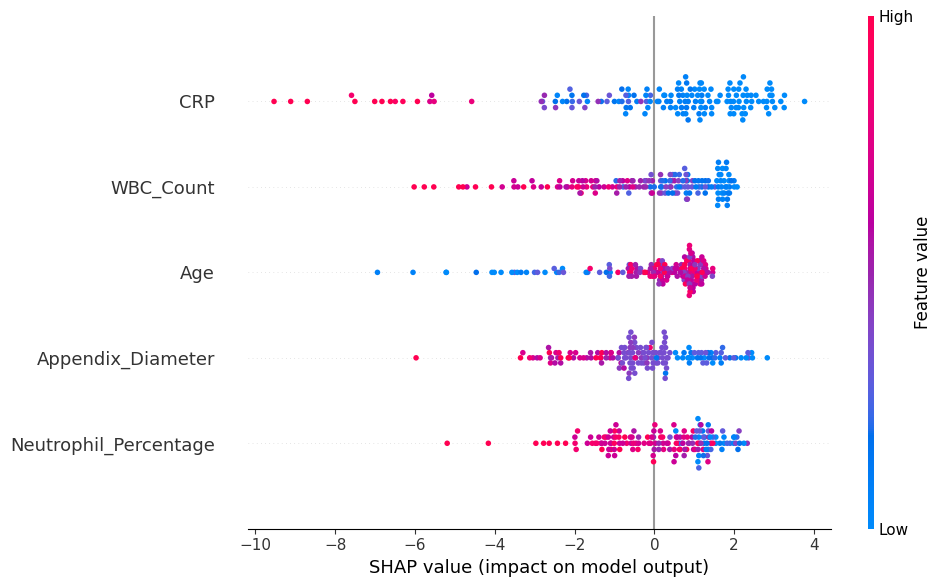

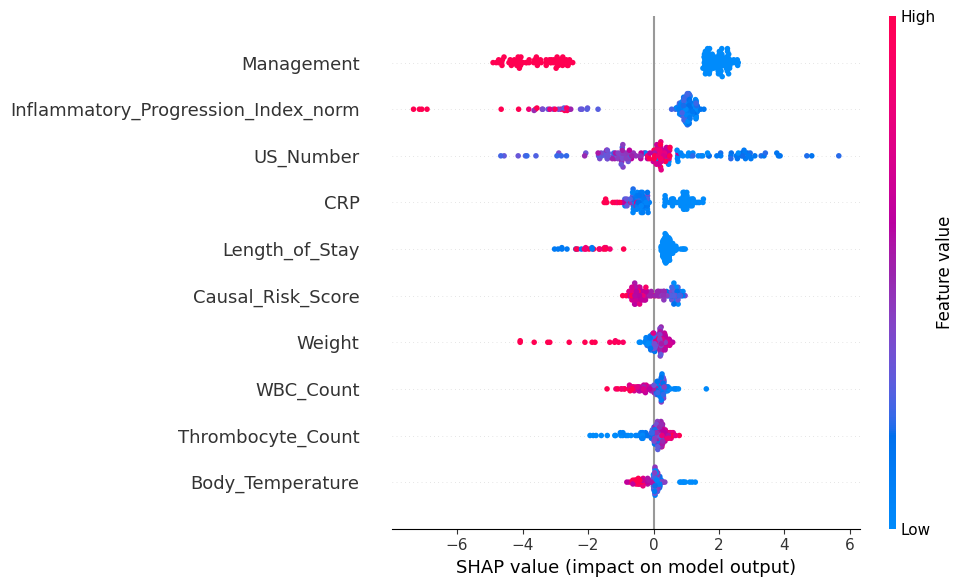

In [ ]:
import shap

# Baseline SHAP
explainer_base = shap.TreeExplainer(baseline_model)
shap_base = explainer_base.shap_values(Xb_test)

plt.figure(figsize=(10,6))
shap.summary_plot(shap_base, Xb_test, show=True, plot_size=(10,6), max_display=10)

# Ablation SHAP
explainer_ablate = shap.TreeExplainer(ablation_model)
shap_ablate = explainer_ablate.shap_values(Xa_test)

plt.figure(figsize=(10,6))
shap.summary_plot(shap_ablate, Xa_test, show=True, plot_size=(10,6), max_display=10)

In [ ]:
final_output = df_results[[
    "Predicted_Risk",
    "Delayed_Risk",
    "Risk_Delta",
    "Uncertain_Case"
]]

final_output.head()


,Predicted_Risk,Delayed_Risk,Risk_Delta,Uncertain_Case
160,0.000063,0.000053,0.000009,0
159,0.002567,0.002182,0.000385,0
243,0.000169,0.000143,0.000025,0
525,0.863685,0.734133,0.129553,0
27,0.000130,0.000111,0.000020,0
